In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import Python libraries --!

import torch
import numpy as np
import matplotlib.pyplot as plt

import kind
import ex_duffing
import reinforcement_learning as rl

In [2]:
# --! duffing environments --!

state_ndim = 2
action_ndim = 1

state_cost = 1.0 * np.eye(state_ndim)
action_cost = 1.0 * np.eye(action_ndim)

dt = 2e-2
setpoint = [1.0, 0.0]

reward_nom = ex_duffing.duffing_reward(state_cost, action_cost, setpoint, beta=1.0, lambda_E=0.05)
reward_exc = ex_duffing.duffing_reward(state_cost, action_cost, setpoint, beta=20.0, lambda_E=0.1)

duffing_nom = ex_duffing.duffing_adapter(ex_duffing.make_duffing('nom', reward_nom, dt=dt))
duffing_exc = ex_duffing.duffing_adapter(ex_duffing.make_duffing('exc', reward_exc, dt=dt))

In [3]:
# --! make a base policy --!

base_policy = ex_duffing.make_base_policy(
    duffing_nom.env.alpha, duffing_nom.env.delta,
    q=state_cost, r=action_cost,
    dt=dt,
    setpoint=setpoint)

In [4]:
# --! specify kind arguments --!

parser = kind.create_args_parser()

args = parser.parse_args(
    args=[
        '--file_dir', '../../data/dreamer',
        '--file_name', 'duffing',
        '--data_nsample', '3848',
        '--feature_ndim', '4',
        '--target_ndim', '2',
        '--data_train_size', '0.8',

        '--back_nsample', '384',
        '--fore_nsample', '192',

        '--batch_size', '128',
        '--nepoch', '200',
        '--patience', '20',
        '--checkpoints', '../../models/dreamer',

        '--rez_nsample_nom', '192',
        '--rez_nsample_exc', '192',
        '--embed_nom', '{"sin": 4, "cos": 4}',
        '--embed_exc', '{"data": 12}',
    ]
)


In [5]:
# --! create factories --!

dataset_factory = ex_duffing.dataset_factory(setpoint)
replay_factory = ex_duffing.replay_factory()

In [6]:
agent = rl.agent(kind.regimes(duffing_nom, duffing_exc), base_policy, dataset_factory, replay_factory, args)


>>> regime separator is computed as 0.029999999329447746
creating new normalizer


saving data with a shape torch.Size([1, 3848, 4]) to a file
saving data with a shape torch.Size([1, 3848, 4]) to a file
>>> regime separator is computed as 0.029999999329447746
>>> training nominal mean >>>
	epoch 1 losses: train=0.293845, valid=0.244857, test=0.245145
	validation loss decreased (inf -> 0.244857), saving model ...
	epoch 2 losses: train=0.242768, valid=0.241647, test=0.241819
	validation loss decreased (0.244857 -> 0.241647), saving model ...
	epoch 3 losses: train=0.241427, valid=0.241264, test=0.241431
	validation loss decreased (0.241647 -> 0.241264), saving model ...
	epoch 4 losses: train=0.241273, valid=0.241228, test=0.241368
	validation loss decreased (0.241264 -> 0.241228), saving model ...
	epoch 5 losses: train=0.241221, valid=0.241183, test=0.241340
	validation loss decreased (0.241228 -> 0.241183), saving model ...
	epoch 6 losses: train=0.241167, valid=0.241118, test=0.241272
	validation loss decreased (0.241183 -> 0.241118), saving model ...
	epoch 7 los

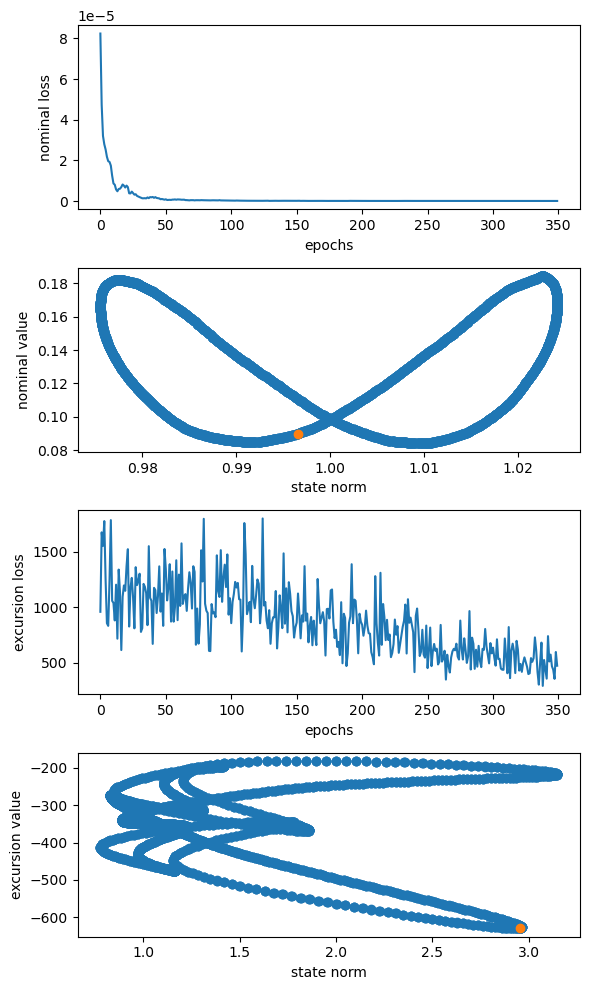

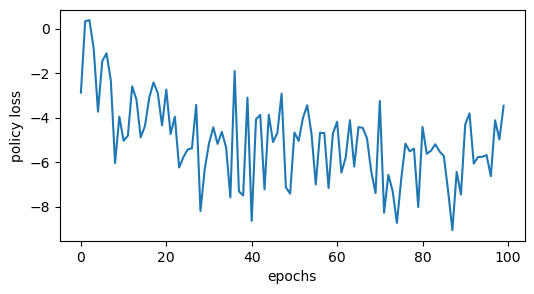

regimes(nominal=tensor(0.0008), excursion=tensor(0.4600))
>>> regime separator is computed as 0.029999999329447746
saving data with a shape torch.Size([1, 3848, 4]) to a file
saving data with a shape torch.Size([1, 3848, 4]) to a file
>>> regime separator is computed as 0.029999999329447746
>>> training nominal mean >>>
	epoch 1 losses: train=0.269613, valid=0.245113, test=0.245553
	validation loss decreased (inf -> 0.245113), saving model ...
	epoch 2 losses: train=0.243222, valid=0.242058, test=0.242519
	validation loss decreased (0.245113 -> 0.242058), saving model ...
	epoch 3 losses: train=0.241555, valid=0.238423, test=0.238941
	validation loss decreased (0.242058 -> 0.238423), saving model ...
	epoch 4 losses: train=0.199465, valid=0.122496, test=0.126513
	validation loss decreased (0.238423 -> 0.122496), saving model ...
	epoch 5 losses: train=0.054637, valid=0.011275, test=0.011640
	validation loss decreased (0.122496 -> 0.011275), saving model ...
	epoch 6 losses: train=0.004

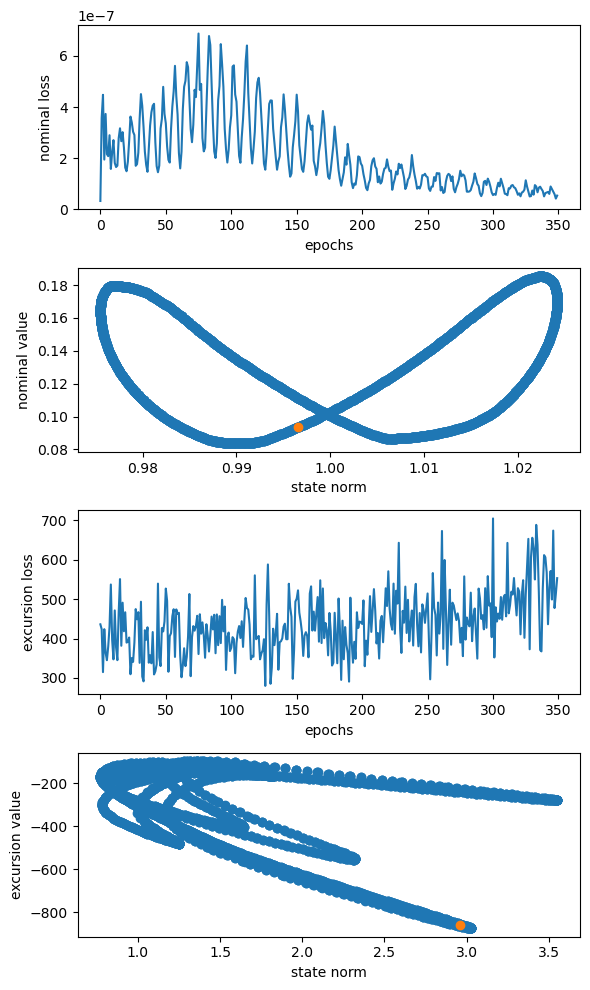

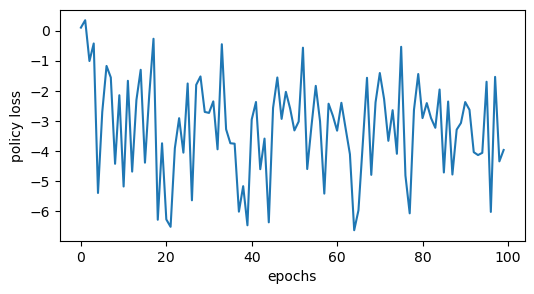

regimes(nominal=tensor(0.0007), excursion=tensor(0.5034))
>>> regime separator is computed as 0.029999999329447746


In [7]:
agent.train(niter=2)